# Load The Dataset

In [38]:
import numpy as np 
import pandas as pd 
import os 
def load_kaggle_comp_data(filename, dataset_slug):
    """
    Automatically detects the environment and loads a CSV file 
    using either the local path or the Kaggle server path.
    
    Parameters:
    - filename (str): The name of the file (e.g., 'patients.csv')
    - dataset_slug (str): The dataset folder name used on Kaggle (e.g., 'username/dataset_name')
    """

    kaggle_path = os.path.join('/kaggle/input/competitions/titanic', dataset_slug, filename)
  
    if os.path.exists(kaggle_path):
        print(f"✈️ Running on Kaggle. Loading: {kaggle_path}")
        return pd.read_csv(kaggle_path)
    else:
        print(f"🏠 Running locally. Loading: {filename}")
        return pd.read_csv('../data/competitions/titanic/'+filename)

test_data = load_kaggle_comp_data("test.csv","competitions/titanic")
train_data = load_kaggle_comp_data("train.csv","competitions/titanic")

🏠 Running locally. Loading: test.csv
🏠 Running locally. Loading: train.csv


# Overview Dataset

In [39]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [40]:
train_data.shape

(891, 12)

In [41]:
train_data.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

# Data Visualization

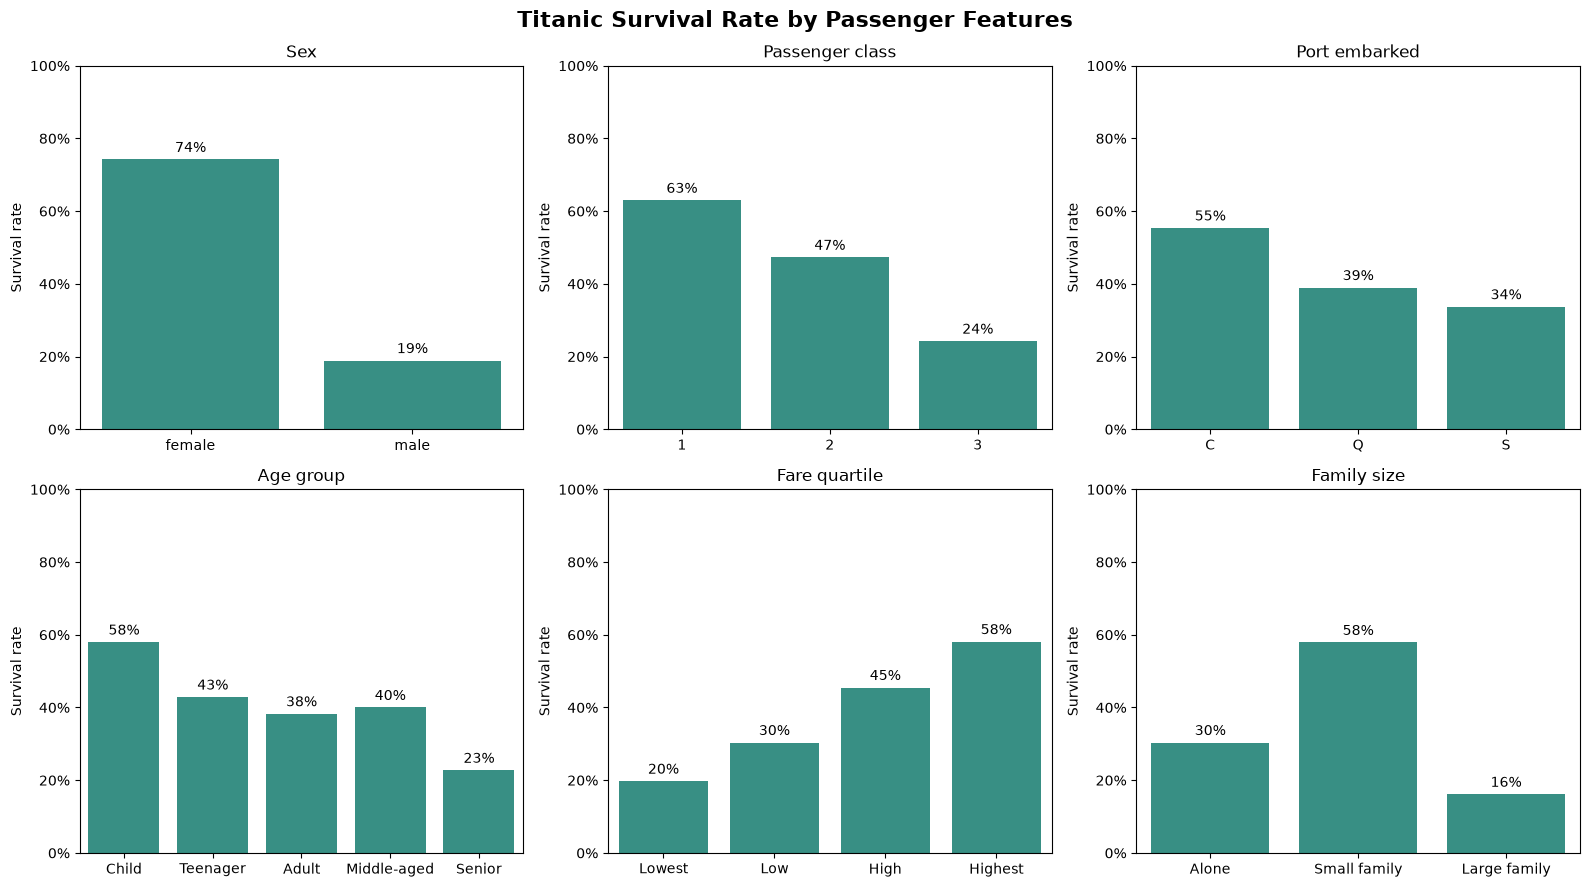

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = train_data.copy()
plot_data["Age group"] = pd.cut(
    plot_data["Age"],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=["Child", "Teenager", "Adult", "Middle-aged", "Senior"],
)
plot_data["Fare group"] = pd.qcut(
    plot_data["Fare"],
    q=4,
    labels=["Lowest", "Low", "High", "Highest"],
    duplicates="drop",
)
plot_data["Family size"] = plot_data["SibSp"] + plot_data["Parch"] + 1
plot_data["Family group"] = pd.cut(
    plot_data["Family size"],
    bins=[0, 1, 4, np.inf],
    labels=["Alone", "Small family", "Large family"],
)

features = [
    ("Sex", "Sex"),
    ("Pclass", "Passenger class"),
    ("Embarked", "Port embarked"),
    ("Age group", "Age group"),
    ("Fare group", "Fare quartile"),
    ("Family group", "Family size"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Titanic Survival Rate by Passenger Features", fontsize=16, fontweight="bold")

for axis, (column, title) in zip(axes.flat, features):
    summary = plot_data.groupby(column, observed=False)["Survived"].mean().reset_index()
    sns.barplot(data=summary, x=column, y="Survived", ax=axis, color="#2a9d8f")
    axis.set_title(title)
    axis.set_xlabel("")
    axis.set_ylabel("Survival rate")
    axis.set_ylim(0, 1)
    axis.bar_label(
        axis.containers[0],
        labels=[f"{bar.get_height():.0%}" for bar in axis.containers[0]],
        padding=3,
    )
    axis.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

plt.tight_layout()
plt.show()


# Feature Engineering

In [43]:
train_data = train_data.drop(["Cabin","Name","Ticket","Embarked"],axis=1)

In [44]:
encoded_data = pd.get_dummies(train_data,columns=["Pclass","Sex"])

In [45]:
correlation_matrix = encoded_data.corr()["Survived"].sort_values(ascending=False)
correlation_matrix

Survived       1.000000
Sex_female     0.543351
Pclass_1       0.285904
Fare           0.257307
Pclass_2       0.093349
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass_3      -0.322308
Sex_male      -0.543351
Name: Survived, dtype: float64

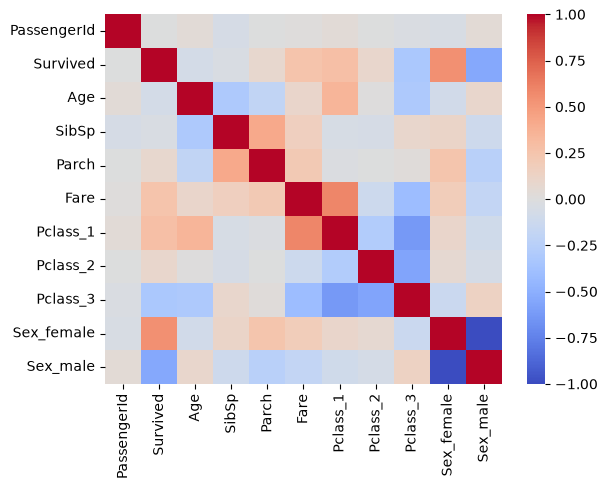

<Figure size 1200x1200 with 0 Axes>

In [46]:
import seaborn as sns
sns.heatmap(encoded_data.corr(), cmap='coolwarm')
plt.figure(figsize=(12, 12))
plt.show()   

## New Features

# Model Traning 

In [47]:
from sklearn.model_selection import train_test_split

X = encoded_data[["Sex_female","Pclass_1","Pclass_2","Pclass_3","Fare","Sex_male"]]

y = encoded_data["Survived"]

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [48]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier()

DT.fit(X_train,y_train)

y_pred = DT.predict(X_test)


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.85       105
           1       0.83      0.72      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

